In [1]:
import sys
print(sys.executable)

d:\TCS project\fake_job_detector\venv\Scripts\python.exe


Shape: (17880, 18)

Column Names:
 ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

First 5 rows:
    job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cl

C:\Users\Abhi\AppData\Local\Temp\ipykernel_7216\1828767852.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraudulent', data=df, palette=['steelblue','crimson'])


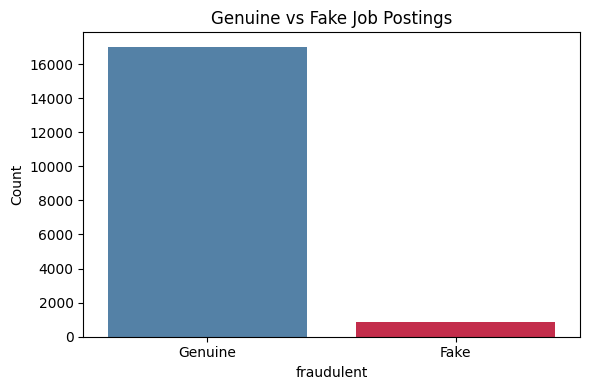


Percentage of Fake postings: 4.84 %


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('fake_job_postings.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['fraudulent'].value_counts())

# Visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df, palette=['steelblue','crimson'])
plt.title('Genuine vs Fake Job Postings')
plt.xticks([0,1], ['Genuine', 'Fake'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

print("\nPercentage of Fake postings:", 
      round(df['fraudulent'].value_counts()[1] / len(df) * 100, 2), "%")

In [3]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import string

nltk.download('stopwords')

# Load dataset
df = pd.read_csv('fake_job_postings.csv')

# Step 1 - Combine important text columns into one
df['text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('')
)

# Step 2 - Clean the text
def clean_text(text):
    # Lowercase everything
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove stopwords (common words like "the", "is", "and")
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)

# Step 3 - Check results
print("Original text sample:")
print(df['text'][0][:300])
print("\nCleaned text sample:")
print(df['cleaned_text'][0][:300])
print("\nTotal records cleaned:", len(df))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abhi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Original text sample:
Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and 

Cleaned text sample:
marketing intern food52 weve created groundbreaking awardwinning cooking site support connect celebrate home cooks give everything need one placewe top editorial business engineering team focused using technology find new better ways connect people around specific food interests offer superb highly 

Total records cleaned: 17880


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Step 1 - Separate input (X) and output (y)
X = df['cleaned_text']  # the text we cleaned
y = df['fraudulent']    # 0 = genuine, 1 = fake

# Step 2 - Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# Step 3 - Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Step 4 - Check shapes
print("Total dataset size:", X_tfidf.shape)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTF-IDF done! Text converted to numbers successfully.")

Total dataset size: (17880, 5000)
Training set size: (14304, 5000)
Testing set size: (3576, 5000)

TF-IDF done! Text converted to numbers successfully.


Model training done!

Accuracy: 96.42 %

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.97      0.98      3395
        Fake       0.60      0.87      0.71       181

    accuracy                           0.96      3576
   macro avg       0.80      0.92      0.85      3576
weighted avg       0.97      0.96      0.97      3576



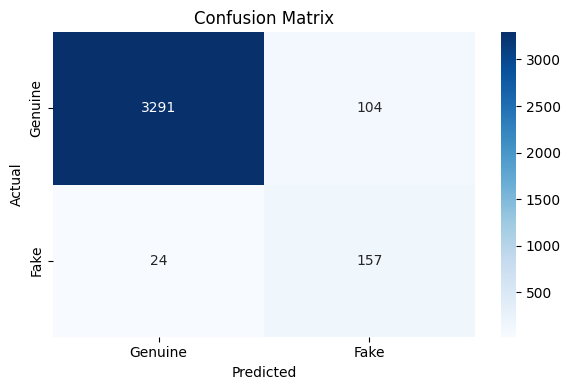

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1 - Train the model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
print("Model training done!")

# Step 2 - Test the model
y_pred = model.predict(X_test)

# Step 3 - Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Step 4 - Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fake']))

# Step 5 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Fake'],
            yticklabels=['Genuine','Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [6]:
import pickle

# Save the model and tfidf vectorizer
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved successfully!")
print("Files created: model.pkl, tfidf.pkl")

Model saved successfully!
Files created: model.pkl, tfidf.pkl
